In [35]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

R = 0.3 #[cMpc/h] 

#logr_min = -3
#logr_max = 3
#dlogr = 0.0001
#Nr = int(( logr_max - logr_min ) / dlogr )
#print(Nr)
#logr_list = [ logr_min + dlogr * i for i in range(Nr) ]
#r_list = [ 10 ** logr for logr in logr_list ]
dlogk = 0.02
logkmin = -1.5
logkmax = 1.5
Nk = int( (logkmax - logkmin) / dlogk )
logks = [ logkmin + dlogk * i for i in range(Nk) ]

def lognormal(logk_list, sigma, R):
    #dr = 0.00003
    dr = 0.03
    rmax = 3
    Nr = int( rmax / dr )
    print(Nr)
    r_list = [ dr * (i+1) for i in range(Nr) ]


    

    k_list = [ 10 ** logk for logk in logk_list ]






    for sigma in [sigma]:
        Pk = np.zeros(Nk)

        fr_list = []
        cf_list = []
        for i, k in enumerate(k_list):
            for r in r_list:
                x = np.log10( r / R ) / np.sqrt(2) / sigma
                fr = 1 - 0.5 * ( 1. + scipy.special.erf(x) )
                if sigma == 0:
                    fr = 1
                Pk[i] += - dr * 4. * np.pi * r**2 * np.sin(k * r) / (k * r) * fr
                if i == 0:
                    fr_list.append(fr)
                    cf_list.append(1-np.array(fr)-1)

    #plt.plot(np.array(r_list), np.array(fr_list))
    return cf_list, Pk



In [31]:
kcoef = np.array(k_list)**3/(2*np.pi**2)

In [26]:
dr = 0.03
rmax = 3
Nr = int( rmax / dr )
print(Nr)
r_list = [ dr * (i+1) for i in range(Nr) ]

100


In [27]:
cf01, Pk01 = lognormal(logks, sigma=0.1, R=0.3)

100


In [40]:
cf001, Pk001 = lognormal(logks, sigma=0.01, R=0.3)

100


In [36]:
cf0, Pk0 = lognormal(logks, sigma=0, R=0.3)

100


/tmp/ipykernel_16006/1884908921.py:44: RuntimeWarning: divide by zero encountered in double_scalars
  x = np.log10( r / R ) / np.sqrt(2) / sigma
/tmp/ipykernel_16006/1884908921.py:44: RuntimeWarning: invalid value encountered in double_scalars
  x = np.log10( r / R ) / np.sqrt(2) / sigma


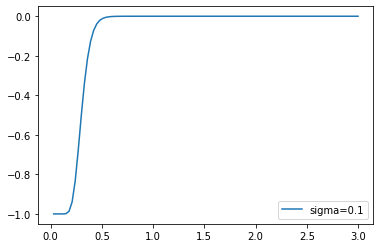

In [29]:
plt.plot(r_list, cf01, label="sigma=0.1")
plt.legend()

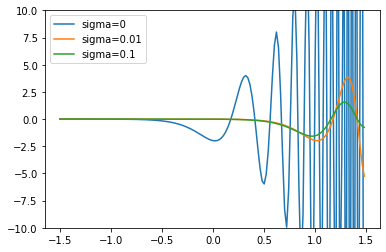

In [43]:
plt.plot(logks,kcoef*Pk0, label="sigma=0")

plt.plot(logks,kcoef*Pk001, label="sigma=0.01")
plt.plot(logks,kcoef*Pk01, label="sigma=0.1")
plt.ylim(-10,10)
plt.legend()

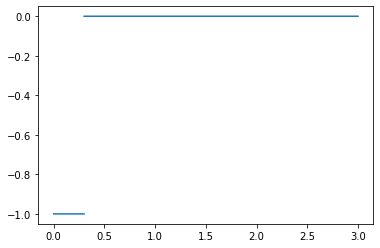

In [13]:
plt.plot(np.array(r_list), 1-np.array(fr_list)-1)

In [ ]:
plt.figure()
plt.title(f"R = {R}")
plt.plot(np.array(logk_list), Pk * np.array(k_list)**3/(2*np.pi**2), label=f"sigma: {sigma}")

plt.legend()

plt.show(block=False)

100000


/tmp/ipykernel_16006/2423513976.py:40: RuntimeWarning: divide by zero encountered in double_scalars
  x = np.log10( r / R ) / np.sqrt(2) / sigma
/tmp/ipykernel_16006/2423513976.py:40: RuntimeWarning: invalid value encountered in double_scalars
  x = np.log10( r / R ) / np.sqrt(2) / sigma


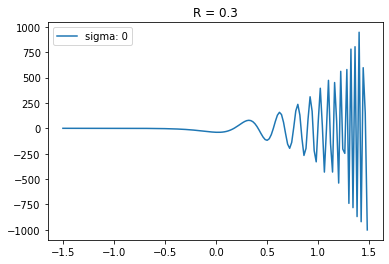

In [7]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

R = 0.3 #[cMpc/h] 

#logr_min = -3
#logr_max = 3
#dlogr = 0.0001
#Nr = int(( logr_max - logr_min ) / dlogr )
#print(Nr)
#logr_list = [ logr_min + dlogr * i for i in range(Nr) ]
#r_list = [ 10 ** logr for logr in logr_list ]

dr = 0.00003
rmax = 3
Nr = int( rmax / dr )
print(Nr)
r_list = [ dr * (i+1) for i in range(Nr) ]

dlogk = 0.02
logkmin = -1.5
logkmax = 1.5
Nk = int( (logkmax - logkmin) / dlogk )
logk_list = [ logkmin + dlogk * i for i in range(Nk) ]
k_list = [ 10 ** logk for logk in logk_list ]




plt.figure()
plt.title(f"R = {R}")

for sigma in [0]:
    Pk_sigma0 = np.zeros(Nk)

    fr_list = []
    for i, k in enumerate(k_list):
        for r in r_list:
            #x = np.log10( r / R ) / np.sqrt(2) / sigma
            #fr = 1 - 0.5 * ( 1. + scipy.special.erf(x) )

            Pk_sigma0[i] += - dr * 4. * np.pi * r**2 * np.sin(k * r) / (k * r)
            if i == 0:
                fr_list.append(fr)

    #plt.plot(np.array(r_list), np.array(fr_list))
plt.plot(np.array(logk_list), Pk_sigma0 * np.array(k_list)**3/(2*np.pi**2), label=f"sigma: {sigma}")

plt.legend()

plt.show(block=False)
#input("Hit Enter to close")
#plt.close()